# Bulgarian Day-Ahead Market — price exploration (v0)

Twelve months of BG day-ahead prices (ENTSO-E) and Sofia temperature (Open-Meteo), on one
hourly grid. **No model here** — this notebook decides what v1 should build.

## Prepare the environment

### Install the libraries

Implementing the install_if_not_installed function for reader simplicity
Add/remove all the necessary packages

In [1]:
%%capture
import importlib
import subprocess
import sys


def install_if_not_installed(package, module=None):
    try:
        importlib.import_module(module or package.replace("-", "_"))
        print(f"{package} is already installed.")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


# List of packages to install  (PyPI name, import name where they differ)
packages = [
    ("pandas", None),
    ("numpy", None),
    ("pyarrow", None),
    ("plotly", None),
    ("matplotlib", None),
    ("seaborn", None),
    ("requests", None),
    ("entsoe-py", "entsoe"),
    ("python-dotenv", "dotenv"),
]

for package, module in packages:
    install_if_not_installed(package, module)

### Import the libraries

In [2]:
import calendar
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.templates.default = "plotly_white"
try:                                   # a static PNG copy too, so figures show on GitHub
    pio.to_image(go.Figure(), format="png")
    pio.renderers.default = "notebook_connected+png"
    pio.renderers["png"].width, pio.renderers["png"].scale = 1100, 1
except Exception:
    pio.renderers.default = "notebook_connected"
sns.set_theme(style="dark")

SEQ = "Viridis"   # magnitude
DIV = "RdBu"      # signed, centred on zero

FIG_DIR = Path("../docs/figures")      # the README embeds these PNGs


def save(fig, name):
    """Write a PNG copy of a figure for the README; skipped quietly without Kaleido."""
    try:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        if hasattr(fig, "write_image"):
            fig.write_image(FIG_DIR / f"{name}.png", width=1100, scale=1)
        else:
            fig.savefig(FIG_DIR / f"{name}.png", dpi=100, bbox_inches="tight")
    except Exception:
        pass


### Settings — the only cell you need to edit
`REFRESH = True` re-downloads from ENTSO-E (needs a key in `../.env`); the default reads the cache in `../data`.


In [3]:
TZ    = "Europe/Sofia"
START = pd.Timestamp("2025-08-01", tz=TZ)
END   = pd.Timestamp("2026-08-01", tz=TZ)          # exclusive -> exactly 12 months
ZONE  = "BG"
LAT, LON = 42.70, 23.32                            # Sofia, national proxy

SWITCH = pd.Timestamp("2025-10-01", tz=TZ)         # BG moves to 15-minute settlement
DST    = ["2025-10-26", "2026-03-29"]              # the 25-hour and 23-hour days

DATA_DIR        = Path("../data")               # notebooks/ is the working directory
CACHE           = DATA_DIR / "v0_hourly.parquet"
RAW_PRICE_CACHE = DATA_DIR / "raw" / "v0_prices_raw.parquet"
RAW_WX_CACHE    = DATA_DIR / "raw" / "v0_weather_raw.parquet"
REFRESH = False                                    # True forces a re-download

MONTH_ORDER = [8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7]          # Aug 2025 -> Jul 2026
MONTH_LABEL = [calendar.month_abbr[m] for m in MONTH_ORDER]
HOURS = list(range(24))

## Read and check data

In [4]:
def fetch_prices():
    from entsoe import EntsoePandasClient
    from dotenv import load_dotenv
    load_dotenv(Path("../.env"))                    # the key lives in a git-ignored .env
    key = os.environ.get("ENTSOE_API_KEY")
    if not key:
        raise RuntimeError("REFRESH needs an ENTSO-E key: cp .env.example .env and paste it there.")
    s = EntsoePandasClient(api_key=key).query_day_ahead_prices(ZONE, start=START, end=END)
    return s.rename("dam_price_eur_mwh")


def fetch_weather():
    import requests
    pad = pd.Timedelta(days=1)          # UTC -> Sofia shift must not clip the window
    r = requests.get("https://archive-api.open-meteo.com/v1/archive", timeout=60, params={
        "latitude": LAT, "longitude": LON,
        "start_date": (START - pad).strftime("%Y-%m-%d"),
        "end_date": (END + pad).strftime("%Y-%m-%d"),
        "hourly": "temperature_2m", "timezone": "UTC"})
    r.raise_for_status()
    w = pd.DataFrame(r.json()["hourly"])
    w["time"] = pd.to_datetime(w["time"]).dt.tz_localize("UTC").dt.tz_convert(TZ)
    return w.set_index("time").sort_index()


if CACHE.exists() and not REFRESH:
    df = pd.read_parquet(CACHE)
else:
    RAW_PRICE_CACHE.parent.mkdir(parents=True, exist_ok=True)
    raw_p = (pd.read_parquet(RAW_PRICE_CACHE)["dam_price_eur_mwh"]
             if RAW_PRICE_CACHE.exists() and not REFRESH else fetch_prices())
    raw_w = (pd.read_parquet(RAW_WX_CACHE)
             if RAW_WX_CACHE.exists() and not REFRESH else fetch_weather())
    raw_p.to_frame().to_parquet(RAW_PRICE_CACHE); raw_w.to_parquet(RAW_WX_CACHE)

    grid = pd.date_range(START, END, freq="1h", tz=TZ, inclusive="left")
    df = pd.DataFrame(index=grid)
    df["dam_price_eur_mwh"] = raw_p.resample("1h").mean().reindex(grid)   # 15-min -> hourly mean
    df["temp_c"] = raw_w["temperature_2m"].reindex(grid)
    df.to_parquet(CACHE)

p, temp = df["dam_price_eur_mwh"], df["temp_c"]
hour, month = df.index.hour, df.index.month

assert len(df) == 8760 and df.index.tz is not None
assert not df.index.has_duplicates and df.index.is_monotonic_increasing
assert df.notna().all().all(), "NaNs present"

print(f"{df.index.min():%Y-%m-%d} -> {df.index.max():%Y-%m-%d}   {len(df):,} hours, 0 gaps, 0 NaN")
print(f"DST days: {DST[0]} = {len(df.loc[DST[0]])}h, {DST[1]} = {len(df.loc[DST[1]])}h")
print(f"price  mean {p.mean():.2f}  median {p.median():.2f}  min {p.min():.2f}  max {p.max():.2f} EUR/MWh")
print(f"       {int((p <= 0).sum())} hours <= 0  ({int((p == 0).sum())} exactly 0.00)")
df.describe().round(1)

2025-08-01 -> 2026-07-31   8,760 hours, 0 gaps, 0 NaN
DST days: 2025-10-26 = 25h, 2026-03-29 = 23h
price  mean 107.09  median 108.92  min -79.49  max 478.91 EUR/MWh
       323 hours <= 0  (103 exactly 0.00)


,dam_price_eur_mwh,temp_c
count,8760.0,8760.0
mean,107.1,11.8
std,59.0,9.0
min,-79.5,-10.3
25%,81.7,4.6
50%,108.9,10.7
75%,137.7,18.6
max,478.9,35.1


### Understanding the data

1. **Complete**: 8,760 of 8,760 hours, both columns, no interpolation anywhere.
2. **Settlement change**: BG moved to 15-minute MTU on 1 Oct 2025; quarter-hours are averaged to hourly means.
3. **Bimodal**: mean 107 EUR/MWh but 323 hours sit at or below zero — the tail is a second regime, not noise.

points/day : 24 before 1 Oct  ->  96 after   (30,645 raw points)
intra-hour spread lost to averaging : 0.00  ->  30.20 EUR/MWh mean  (max 95)


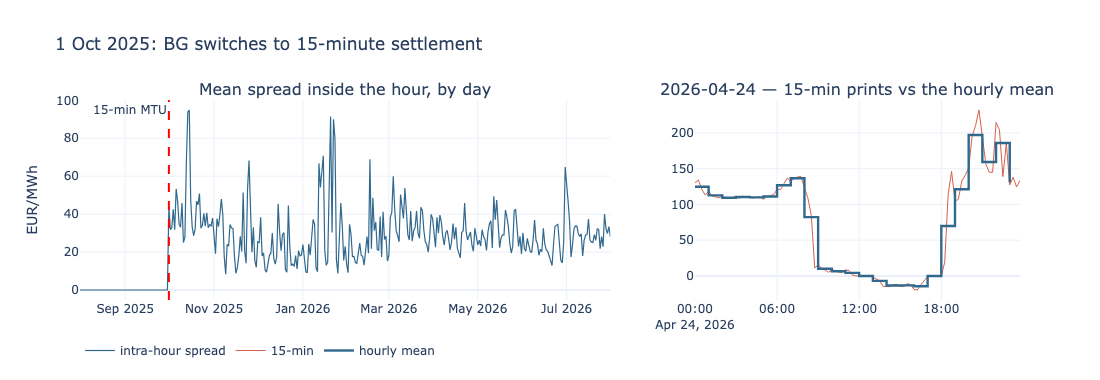

In [5]:
# What the hourly average costs us: intra-hour spread before vs after the MTU switch.
if RAW_PRICE_CACHE.exists():
    raw = pd.read_parquet(RAW_PRICE_CACHE)["dam_price_eur_mwh"]
    raw = raw[(raw.index >= START) & (raw.index < END)]            # drop the stray point at END
    per_day = raw.groupby(raw.index.normalize()).size()
    hh = raw.groupby([raw.index.normalize(), raw.index.hour]).agg(["min", "max"])
    spread = (hh["max"] - hh["min"]).groupby(level=0).mean()
    pre, post = spread.index < SWITCH, spread.index >= SWITCH

    print(f"points/day : {per_day[per_day.index < SWITCH].mode()[0]:.0f} before 1 Oct"
          f"  ->  {per_day[per_day.index >= SWITCH].mode()[0]:.0f} after   ({len(raw):,} raw points)")
    print(f"intra-hour spread lost to averaging : {spread[pre].mean():.2f}"
          f"  ->  {spread[post].mean():.2f} EUR/MWh mean  (max {spread[post].max():.0f})")

    day = "2026-04-24"
    fig = make_subplots(1, 2, column_widths=[.62, .38], horizontal_spacing=.09,
                        subplot_titles=("Mean spread inside the hour, by day",
                                        f"{day} — 15-min prints vs the hourly mean"))
    fig.add_scatter(x=spread.index.tz_localize(None), y=spread.round(1), name="intra-hour spread",
                    line=dict(color="#31688e", width=1.2), row=1, col=1)
    fig.add_vline(x=SWITCH.tz_localize(None), line=dict(color="red", width=2, dash="dash"),
                  annotation_text="15-min MTU", annotation_position="top left", row=1, col=1)
    fig.add_scatter(x=raw.loc[day].index.tz_localize(None), y=raw.loc[day].round(1),
                    name="15-min", line=dict(color="#d6604d", width=1), row=1, col=2)
    fig.add_scatter(x=p.loc[day].index.tz_localize(None), y=p.loc[day].round(1),
                    name="hourly mean", line=dict(color="#31688e", width=2.4, shape="hv"), row=1, col=2)
    fig.update_layout(height=380, title="1 Oct 2025: BG switches to 15-minute settlement",
                      legend=dict(orientation="h", y=-0.18))
    fig.update_yaxes(title_text="EUR/MWh", row=1, col=1)
    fig.show()
    save(fig, "eda_1_mtu_switch")
else:
    print("raw 15-min cache absent — figure skipped")

# DAM analysis

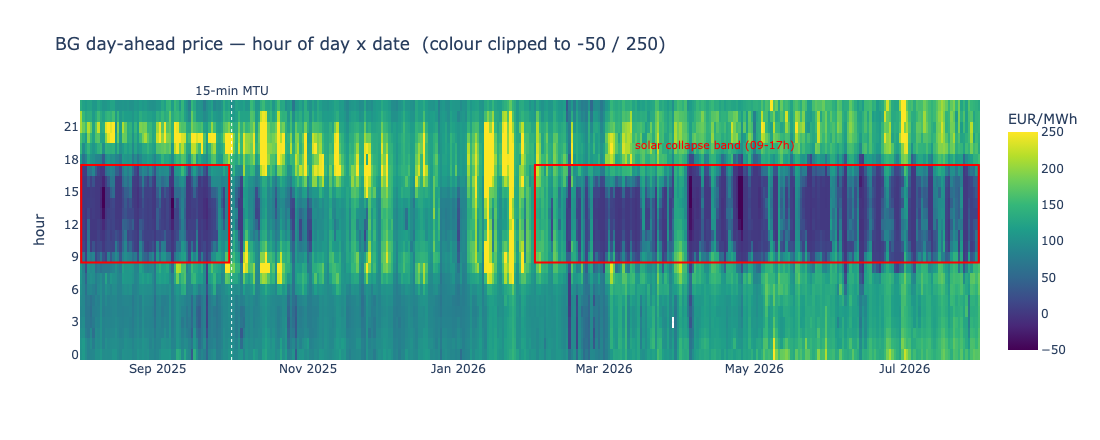

capture ratio   18:00-21:00 1.48x (158.5)   |   09:00-16:00 0.65x (69.9)
weekday 116.1  vs  weekend 84.4 EUR/MWh


In [6]:
d = p.to_frame("v")
d["hour"] = hour
d["date"] = df.index.normalize().tz_localize(None)
hm = d.pivot_table(index="hour", columns="date", values="v", aggfunc="mean")  # collapses the doubled DST hour

fig = go.Figure(go.Heatmap(
    z=hm.round(1), x=hm.columns, y=hm.index, colorscale=SEQ,
    zmin=-50, zmax=250,                       # unclipped the 479 max flattens the year
    colorbar=dict(title="EUR/MWh"),
    hovertemplate="%{x|%a %d %b %Y}  %{y:02d}:00 — %{z} EUR/MWh<extra></extra>"))
fig.add_vline(x=SWITCH.tz_localize(None), line=dict(color="white", width=1, dash="dot"),
              annotation_text="15-min MTU", annotation_position="top")
for x0, x1 in [("2025-08-01", "2025-09-30"), ("2026-02-01", "2026-07-31")]:
    fig.add_shape(type="rect", x0=x0, x1=x1, y0=8.5, y1=17.5,
                  line=dict(color="red", width=2), fillcolor="rgba(0,0,0,0)")
fig.add_annotation(x="2026-04-15", y=19.4, text="solar collapse band (09-17h)",
                   showarrow=False, font=dict(color="red", size=11))
fig.update_layout(height=440, title="BG day-ahead price — hour of day x date  (colour clipped to -50 / 250)",
                  yaxis=dict(title="hour", dtick=3))
fig.show()
save(fig, "eda_2_price_heatmap")

evening, solar = p[(hour >= 18) & (hour <= 21)], p[(hour >= 9) & (hour <= 16)]
print(f"capture ratio   18:00-21:00 {evening.mean() / p.mean():.2f}x ({evening.mean():.1f})"
      f"   |   09:00-16:00 {solar.mean() / p.mean():.2f}x ({solar.mean():.1f})")
print(f"weekday {p[df.index.dayofweek < 5].mean():.1f}  vs  weekend {p[df.index.dayofweek >= 5].mean():.1f} EUR/MWh")

### Understanding DAM

1. **Solar collapse**: midday goes to zero from Feb to Sep and is absent Oct–Jan — the band is seasonal, not permanent.
2. **Evening peak**: 18:00–21:00 captures 1.48x the annual mean while 09:00–16:00 captures 0.65x.
3. **Weekly rhythm**: weekdays average 116 EUR/MWh against 84 at weekends.
4. **Not separable**: the daily shape *inverts* by season, so hour and month interact — an additive model cannot fit this.

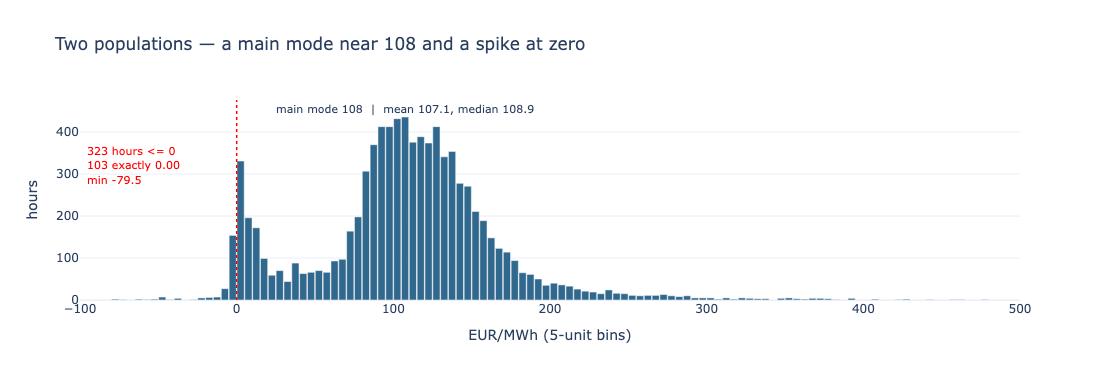

hours in the [0, 5) bin: 331   -> MAE/RMSE only: MAPE, a log target and Box-Cox are all undefined here.


In [7]:
counts, edges = np.histogram(p, bins=np.arange(-100, 505, 5))
mids = edges[:-1] + 2.5
peak = mids[counts.argmax()]

fig = go.Figure(go.Bar(x=mids, y=counts, marker_color="#31688e", width=4.6,
                       hovertemplate="%{x:.0f} EUR/MWh — %{y} hours<extra></extra>"))
fig.add_vline(x=0, line=dict(color="red", width=1.5, dash="dot"))
fig.add_annotation(x=-97, y=counts.max() * .74, xanchor="left", showarrow=False, align="left",
                   font=dict(color="red", size=11),
                   text=f"{int((p <= 0).sum())} hours <= 0<br>{int((p == 0).sum())} exactly 0.00<br>min {p.min():.1f}")
fig.add_annotation(x=peak, y=counts.max(), yanchor="bottom", showarrow=False, font=dict(size=11),
                   text=f"main mode {peak:.0f}  |  mean {p.mean():.1f}, median {p.median():.1f}")
fig.update_layout(height=380, bargap=0,
                  title=f"Two populations — a main mode near {peak:.0f} and a spike at zero",
                  xaxis_title="EUR/MWh (5-unit bins)", yaxis_title="hours")
fig.show()
save(fig, "eda_3_histogram")

print(f"hours in the [0, 5) bin: {int(((p >= 0) & (p < 5)).sum())}   "
      f"-> MAE/RMSE only: MAPE, a log target and Box-Cox are all undefined here.")

### Where the price collapses

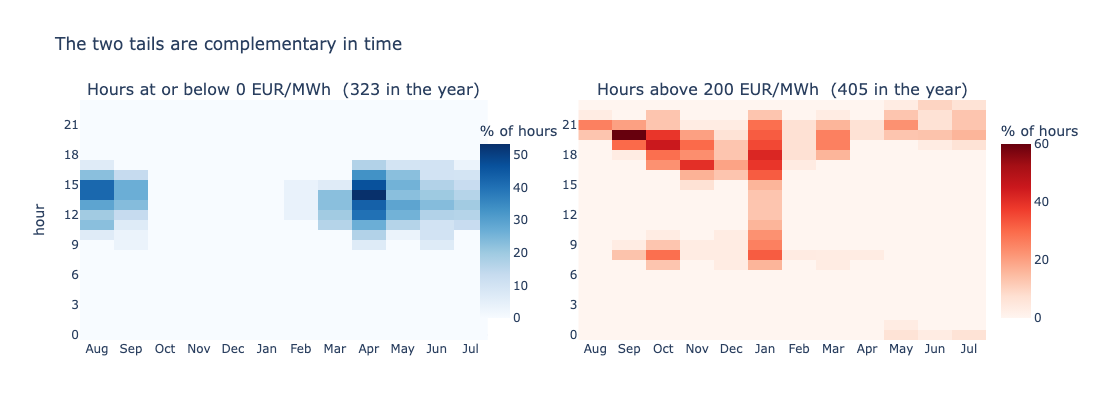

all 323 hours <= 0 fall in 09:00-17:00 ;  66% of hours above 200 fall in 17:00-21:00
P(collapse) = 3.69%   |   given a collapse 48h earlier 21.4%   |   168h earlier 45.5%


In [8]:
low  = (p <= 0).groupby([hour, month]).mean().unstack() * 100
high = (p > 200).groupby([hour, month]).mean().unstack() * 100
low, high = low[MONTH_ORDER], high[MONTH_ORDER]

fig = make_subplots(1, 2, horizontal_spacing=.10,
                    subplot_titles=(f"Hours at or below 0 EUR/MWh  ({int((p <= 0).sum())} in the year)",
                                    f"Hours above 200 EUR/MWh  ({int((p > 200).sum())} in the year)"))
for i, (m, scale) in enumerate([(low, "Blues"), (high, "Reds")], start=1):
    fig.add_heatmap(z=m.round(1), x=MONTH_LABEL, y=m.index, colorscale=scale, zmin=0,
                    colorbar=dict(title="% of hours", x=0.43 if i == 1 else 1.005, len=.9),
                    hovertemplate="%{x} %{y:02d}:00 — %{z}%<extra></extra>", row=1, col=i)
fig.update_layout(height=420, title="The two tails are complementary in time")
fig.update_yaxes(title_text="hour", dtick=3, row=1, col=1)
fig.update_yaxes(dtick=3, row=1, col=2)
fig.show()
save(fig, "eda_4_tails")

hi = p > 200
print(f"all {int((p <= 0).sum())} hours <= 0 fall in {hour[(p <= 0).values].min():02d}:00-"
      f"{hour[(p <= 0).values].max():02d}:00 ;  {100 * (hi & (hour >= 17) & (hour <= 21)).sum() / hi.sum():.0f}%"
      f" of hours above 200 fall in 17:00-21:00")

collapse = (p <= 0).astype(int)
base = collapse.mean()
lift = {L: collapse[collapse.shift(L) == 1].mean() for L in (48, 168)}
print(f"P(collapse) = {100 * base:.2f}%   |   given a collapse 48h earlier {100 * lift[48]:.1f}%"
      f"   |   168h earlier {100 * lift[168]:.1f}%")

### Understanding the tails

1. **Solar fingerprint**: every hour at or below zero falls between 09:00 and 17:00, and only from Feb to Sep — calendar features alone take a classifier most of the way.
2. **Persistence**: a collapse 168h earlier lifts the odds from 3.7% to 45.5%, which argues for classify-then-regress in v1.

### Monthly variability DAM

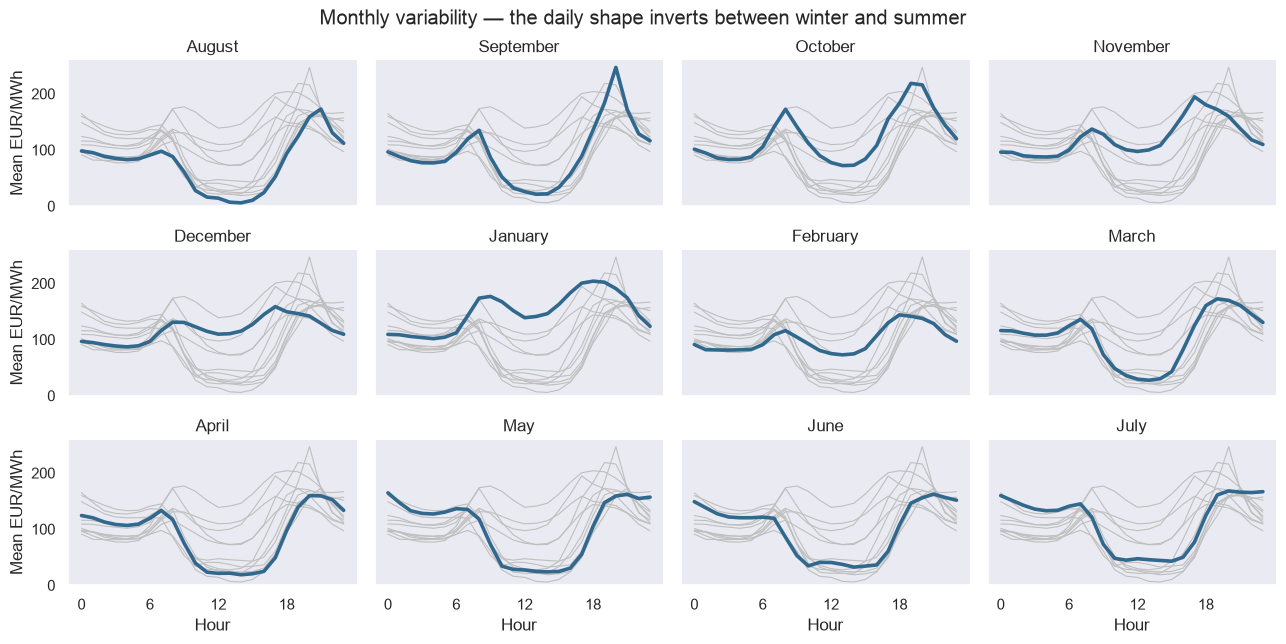

In [9]:
prof = (p.groupby([month, hour]).mean()
         .rename("price").rename_axis(["Month", "Hour"]).reset_index())
prof["MonthName"] = prof["Month"].map(lambda m: calendar.month_name[m])

g = sns.FacetGrid(prof, col="MonthName", col_wrap=4, height=2.1, aspect=1.55,
                  col_order=[calendar.month_name[m] for m in MONTH_ORDER])
g.map(sns.lineplot, "Hour", "price", linewidth=2.6, color="#31688e")
for name, ax in g.axes_dict.items():
    sns.lineplot(data=prof, x="Hour", y="price", units="MonthName", estimator=None,
                 color="0.75", linewidth=0.8, ax=ax, zorder=0)
    ax.set_ylim(0, prof["price"].max() * 1.05)
    ax.set_xticks([0, 6, 12, 18])
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Hour", "Mean EUR/MWh")
g.figure.suptitle("Monthly variability — the daily shape inverts between winter and summer", y=1.02)
g.figure.set_dpi(100)
save(g.figure, "eda_5_monthly_profiles")
plt.show()

### Temperature

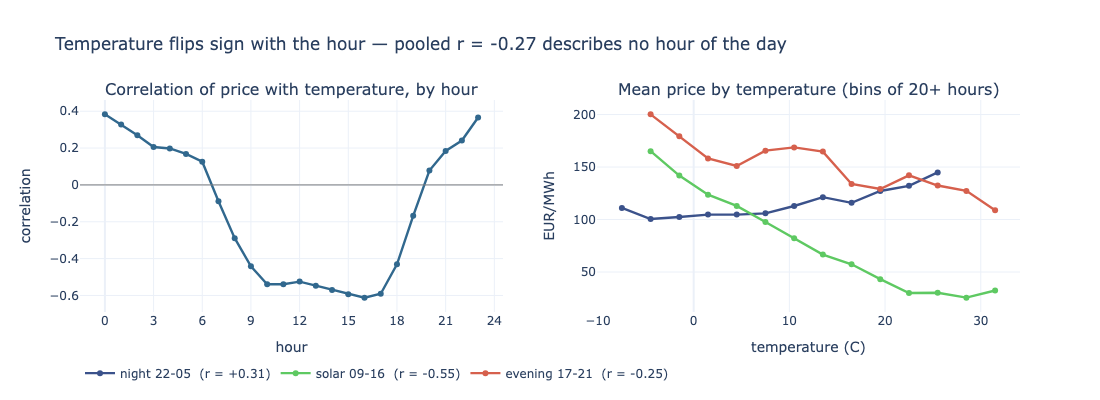

r ranges from +0.38 at 00:00 to -0.61 at 16:00


In [10]:
r_by_hour = pd.Series({h: p[hour == h].corr(temp[hour == h]) for h in HOURS})
blocks = {"night 22-05": (hour >= 22) | (hour <= 5),
          "solar 09-16": (hour >= 9) & (hour <= 16),
          "evening 17-21": (hour >= 17) & (hour <= 21)}
colours = ["#3b528b", "#5ec962", "#d6604d"]

fig = make_subplots(1, 2, horizontal_spacing=.10,
                    subplot_titles=("Correlation of price with temperature, by hour",
                                    "Mean price by temperature (bins of 20+ hours)"))
fig.add_scatter(x=HOURS, y=r_by_hour.round(3), mode="lines+markers",
                line=dict(color="#31688e", width=2.4), showlegend=False, row=1, col=1)
fig.add_hline(y=0, line=dict(color="grey", width=1), row=1, col=1)

bins = np.arange(-12, 39, 3)
for (label, sel), colour in zip(blocks.items(), colours):
    grp = p[sel].groupby(pd.cut(temp[sel], bins), observed=True)
    m, n = grp.mean(), grp.size()
    keep = n >= 20
    fig.add_scatter(x=[iv.mid for iv in m.index[keep]], y=m[keep].round(1), mode="lines+markers",
                    name=f"{label}  (r = {p[sel].corr(temp[sel]):+.2f})",
                    line=dict(color=colour, width=2.4), row=1, col=2)

fig.update_layout(height=400, legend=dict(orientation="h", y=-0.22),
                  title=f"Temperature flips sign with the hour — pooled r = {p.corr(temp):+.2f} describes no hour of the day")
fig.update_xaxes(title_text="hour", dtick=3, row=1, col=1)
fig.update_xaxes(title_text="temperature (C)", row=1, col=2)
fig.update_yaxes(title_text="correlation", row=1, col=1)
fig.update_yaxes(title_text="EUR/MWh", row=1, col=2)
fig.show()
save(fig, "eda_6_temperature")

print(f"r ranges from {r_by_hour.max():+.2f} at {r_by_hour.idxmax():02d}:00 "
      f"to {r_by_hour.min():+.2f} at {r_by_hour.idxmin():02d}:00")

## Forecasting at 08:00

The auction clears before the day starts, so a feature may only use what was published by 08:00 —
every price-derived feature is therefore lagged **at least 48h**.

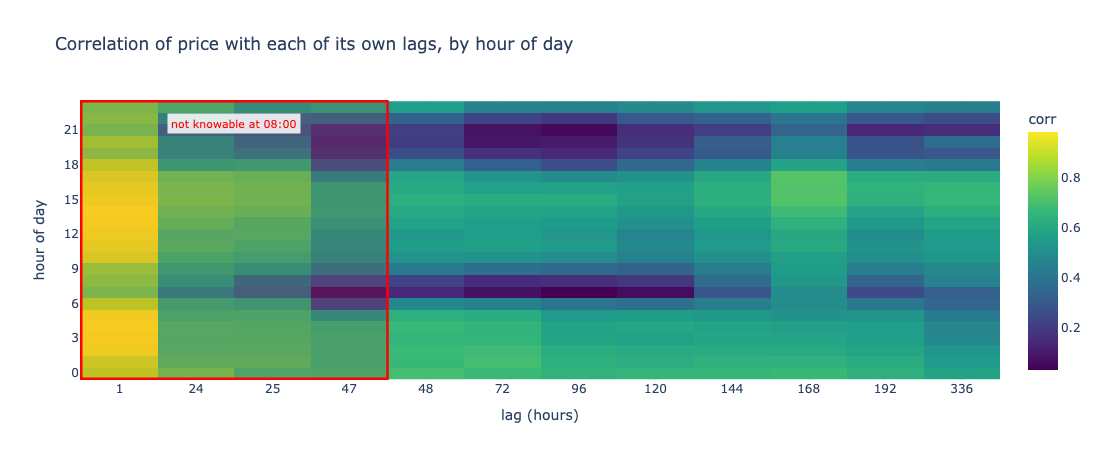

00:00   lag 48h r = +0.69   lag 168h r = +0.67
07:00   lag 48h r = +0.14   lag 168h r = +0.49
15:00   lag 48h r = +0.63   lag 168h r = +0.72
whole series: lag 48h +0.64, lag 168h +0.72 — last week beats the day before yesterday


In [11]:
LAGS = [1, 24, 25, 47, 48, 72, 96, 120, 144, 168, 192, 336]
corr = pd.DataFrame({L: {h: p[hour == h].corr(p.shift(L)[hour == h]) for h in HOURS} for L in LAGS})
legal = [i for i, L in enumerate(LAGS) if L >= 48]

fig = go.Figure(go.Heatmap(z=corr.round(3), x=[str(L) for L in LAGS], y=HOURS, colorscale=SEQ,
                           colorbar=dict(title="corr"),
                           hovertemplate="lag %{x}h at %{y:02d}:00 — r = %{z}<extra></extra>"))
fig.add_shape(type="rect", x0=-.5, x1=min(legal) - .5, y0=-.5, y1=23.5,
              line=dict(color="red", width=2.5), fillcolor="rgba(220,0,0,0.12)")
fig.add_annotation(x=1.5, y=21.6, text="not knowable at 08:00", showarrow=False,
                   font=dict(color="red", size=11), bgcolor="rgba(255,255,255,0.85)",
                   borderpad=3)
fig.update_layout(height=460, xaxis=dict(title="lag (hours)", type="category"),
                  yaxis=dict(title="hour of day", dtick=3),
                  title="Correlation of price with each of its own lags, by hour of day")
fig.show()
save(fig, "eda_7_lag_correlation")

for h in (0, 7, 15):
    print(f"{h:02d}:00   lag 48h r = {corr.loc[h, 48]:+.2f}   lag 168h r = {corr.loc[h, 168]:+.2f}")
print(f"whole series: lag 48h {p.corr(p.shift(48)):+.2f}, lag 168h {p.corr(p.shift(168)):+.2f} "
      f"— last week beats the day before yesterday")

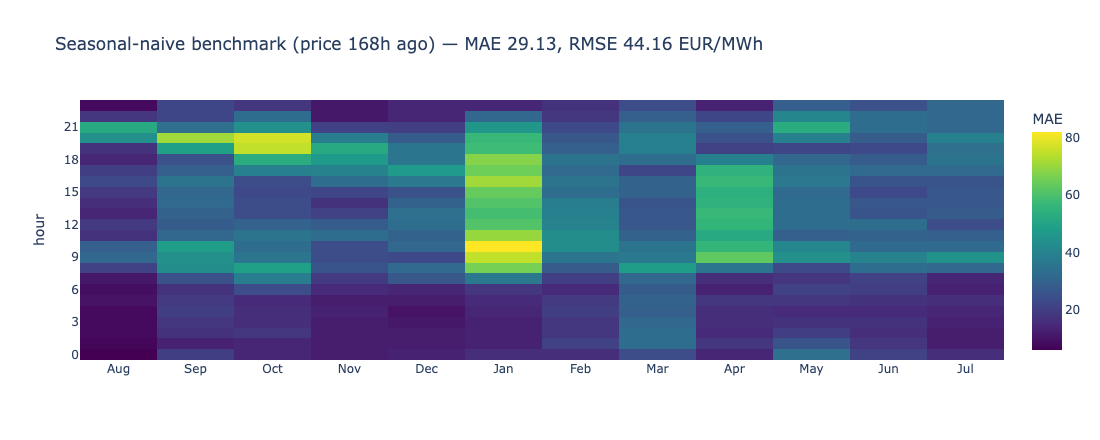

MAE 29.13 overall, but 15.9 at 04:00 against 42.9 at 20:00
           and 17.8 in Aug against 45.3 in Jan
lag-48 naive would score MAE 33.98 — the weekly lag is the better legal baseline


In [12]:
naive = p.shift(168)
ok = naive.notna()
err = (p - naive).abs()
mae, rmse = err[ok].mean(), np.sqrt(((p - naive) ** 2)[ok].mean())

surface = (err[ok].groupby([hour[ok], month[ok]]).mean().unstack())[MONTH_ORDER]

fig = go.Figure(go.Heatmap(z=surface.round(0), x=MONTH_LABEL, y=surface.index, colorscale=SEQ,
                           colorbar=dict(title="MAE"),
                           hovertemplate="%{x} %{y:02d}:00 — MAE %{z} EUR/MWh<extra></extra>"))
fig.update_layout(height=440, yaxis=dict(title="hour", dtick=3),
                  title=f"Seasonal-naive benchmark (price 168h ago) — MAE {mae:.2f}, RMSE {rmse:.2f} EUR/MWh")
fig.show()
save(fig, "eda_8_naive_mae")

eh, em = err[ok].groupby(hour[ok]).mean(), err[ok].groupby(month[ok]).mean()
print(f"MAE {mae:.2f} overall, but {eh.min():.1f} at {eh.idxmin():02d}:00 against {eh.max():.1f} at {eh.idxmax():02d}:00")
print(f"           and {em.min():.1f} in {calendar.month_abbr[em.idxmin()]} against {em.max():.1f} in {calendar.month_abbr[em.idxmax()]}")
print(f"lag-48 naive would score MAE {(p - p.shift(48)).abs().mean():.2f} — the weekly lag is the better legal baseline")

### Findings for v1

1. **Beat MAE 29.13 EUR/MWh** — the seasonal-naive (168h) benchmark, and report it per hour, not just as a scalar.
2. **Price lags 48 / 72 / 144 / 168 / 336h, interacted with hour** — the best lag flips by hour of day (48h wins overnight, 168h wins at 15:00 and rescues 07:00).
3. **hour x month, not hour + month** — the daily profile inverts between winter and summer.
4. **Temperature only inside an hour block** — its correlation runs from +0.38 at midnight to −0.61 at 16:00, so a single linear coefficient is meaningless.
5. **A collapse flag (price <= 0) at lag 168h** as a first pass at classify-then-regress.
6. **MAE headline, RMSE alongside — no MAPE, no log target**: 103 hours are exactly 0.00 and 220 are negative.
7. **What is missing** — ENTSO-E day-ahead load, wind and solar forecasts. They are legal at their own timestamp and they drive every pattern above; adding them is v1's first job.

**Next →** [02_model.ipynb](02_model.ipynb) adds those forecasts, nine years of history and LightGBM.
